In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import joblib
import os

# Pastikan folder models ada
os.makedirs('../models', exist_ok=True)

In [8]:
# Membaca dataset
df = pd.read_csv('../data/credit_risk_dataset.csv')
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [9]:
# === Analisis Missing Value ===
print("=== MISSING VALUE ANALYSIS ===")
print(f"Total baris: {len(df)}")
print(f"\nMissing value per kolom:")
missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Kolom': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing %': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string(index=False))

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Data info:")
print(df.dtypes)

=== MISSING VALUE ANALYSIS ===
Total baris: 32581

Missing value per kolom:
            Kolom  Missing Count  Missing %
    loan_int_rate           3116   9.563856
person_emp_length            895   2.747000

Duplicate rows: 165
Data info:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


In [10]:
# === Data Cleaning (Pembersihan Data) ===
print("\n=== DATA CLEANING ===")

# 1. Hapus duplikasi
df_clean = df.drop_duplicates(subset=None, keep='first').copy()
print(f"Duplikasi dihapus: {len(df) - len(df_clean)} baris")

# 2. Tangani outlier dan nilai invalid
# - person_age: harus 18-100
df_clean = df_clean[(df_clean['person_age'] >= 18) & (df_clean['person_age'] <= 100)]
print(f"Baris dengan usia invalid dihapus: {len(df) - len(df_clean)} baris")

# - person_income: harus positif
df_clean = df_clean[df_clean['person_income'] > 0]
print(f"Baris dengan income <= 0 dihapus: {len(df) - len(df_clean)}")

# - loan_amnt: harus positif
df_clean = df_clean[df_clean['loan_amnt'] > 0]
print(f"Baris dengan loan_amnt <= 0 dihapus: {len(df) - len(df_clean)}")

# - person_emp_length: harus >= 0
df_clean = df_clean[df_clean['person_emp_length'] >= 0]

# 3. Isi missing value untuk kolom penting
print(f"\nSebelum imputasi missing value:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

# Kolom numerik: isi dengan median berdasarkan kategori (loan_grade)
numeric_cols_to_impute = ['person_emp_length', 'loan_int_rate']
for col in numeric_cols_to_impute:
    if df_clean[col].isna().sum() > 0:
        # Isi per grup loan_grade
        df_clean[col] = df_clean.groupby('loan_grade')[col].transform(
            lambda grp: grp.fillna(grp.median())
        )
        # Jika masih ada yang kosong, isi dengan median global
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f"{col}: semua missing value sudah diisi")

# Kolom kategorikal: isi dengan modus (most frequent)
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isna().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"{col}: missing value diisi dengan '{mode_val}'")

print(f"\nSetelah imputasi:")
print(f"Total missing value: {df_clean.isna().sum().sum()}")
print(f"Total baris setelah cleaning: {len(df_clean)}")
print(f"Baris yang dihapus/diubah: {len(df) - len(df_clean)}")

# Gunakan data yang sudah dibersihkan
df = df_clean.copy()



=== DATA CLEANING ===
Duplikasi dihapus: 165 baris
Baris dengan usia invalid dihapus: 170 baris
Baris dengan income <= 0 dihapus: 170
Baris dengan loan_amnt <= 0 dihapus: 170

Sebelum imputasi missing value:
loan_int_rate    3027
dtype: int64
loan_int_rate: semua missing value sudah diisi

Setelah imputasi:
Total missing value: 0
Total baris setelah cleaning: 31524
Baris yang dihapus/diubah: 1057


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27996\2382158772.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns


In [11]:
# Pisahkan fitur dan target
X = df.drop('loan_status', axis=1) # Sesuaikan 'loan_status' dengan nama kolom target Anda
y = df['loan_status']

# === Data cleaning dan feature engineering ===
# Semua persiapan fitur dilakukan dalam satu fungsi agar training pipeline konsisten.

def preprocess_features(df_input):
    df_copy = df_input.copy()

    # 1. Cleaning data / imputasi
    # - Isi missing pada kolom numerik penting berdasarkan grup loan_grade
    # - Isi missing global jika masih ada setelah grup-imputasi
    for col in ['person_emp_length', 'loan_int_rate']:
        df_copy[col] = df_copy.groupby('loan_grade')[col].transform(lambda grp: grp.fillna(grp.median()))
        df_copy[col] = df_copy[col].fillna(df_copy[col].median())

    # 2. Feature recalculation
    # - Hitung ulang loan_percent_income untuk konsistensi data
    df_copy['loan_percent_income'] = df_copy['loan_amnt'] / df_copy['person_income'].replace({0: np.nan})
    df_copy['loan_percent_income'] = df_copy['loan_percent_income'].fillna(df_copy['loan_percent_income'].median())

    # 3. Feature engineering tambahan
    # - Bucket usia, lama kerja, dan suku bunga
    df_copy['person_age_bucket'] = pd.cut(
        df_copy['person_age'],
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'],
        include_lowest=True
    ).astype(object).fillna('missing')

    df_copy['emp_length_bucket'] = pd.cut(
        df_copy['person_emp_length'],
        bins=[0, 1, 3, 5, 10, 20, 100],
        labels=['<1', '1-3', '4-5', '6-10', '11-20', '20+'],
        include_lowest=True
    ).astype(object).fillna('missing')

    df_copy['loan_int_rate_bucket'] = pd.cut(
        df_copy['loan_int_rate'],
        bins=[0, 5, 10, 15, 20, 100],
        labels=['<=5', '5-10', '10-15', '15-20', '>20'],
        include_lowest=True
    ).astype(object).fillna('missing')

    df_copy['loan_income_ratio'] = df_copy['loan_amnt'] / df_copy['person_income'].replace({0: np.nan})
    df_copy['loan_income_ratio'] = df_copy['loan_income_ratio'].replace([np.inf, -np.inf], np.nan)
    df_copy['loan_income_ratio'] = df_copy['loan_income_ratio'].fillna(df_copy['loan_income_ratio'].median())

    # 4. Final cleaning
    # - Pastikan NA bertipe np.nan dan angka numerik dalam tipe float
    df_copy = df_copy.replace({pd.NA: np.nan})
    numeric_cols = [
        'person_age', 'person_income', 'person_emp_length',
        'loan_amnt', 'loan_int_rate', 'loan_percent_income',
        'cb_person_cred_hist_length', 'loan_income_ratio'
    ]
    df_copy[numeric_cols] = df_copy[numeric_cols].astype(float)

    return df_copy

# Terapkan preprocessing fitur tambahan sebelum menentukan kolom
X = preprocess_features(X)

# Identifikasi kolom numerik dan kategorikal setelah feature engineering
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'string']).columns

# === Preprocessing pipeline ===
# Pipeline numerik: imputasi + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline kategorikal: imputasi + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan transformer numerik dan kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [12]:
# === Hyperparameter grid untuk pencarian terbaik ===
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

In [13]:
# === Model training ===
feature_adder = FunctionTransformer(preprocess_features, validate=False)
clf = Pipeline(steps=[
    ('feature_adder', feature_adder),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Hyperparameter tuning
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')

# Split data train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)
print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Akurasi: {grid_search.score(X_test, y_test)}")
print(f"F1 score: {f1_score(y_test, y_pred)}")

Parameter terbaik: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Akurasi: 0.806930693069307
F1 score: 0.806930693069307


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27996\201269232.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


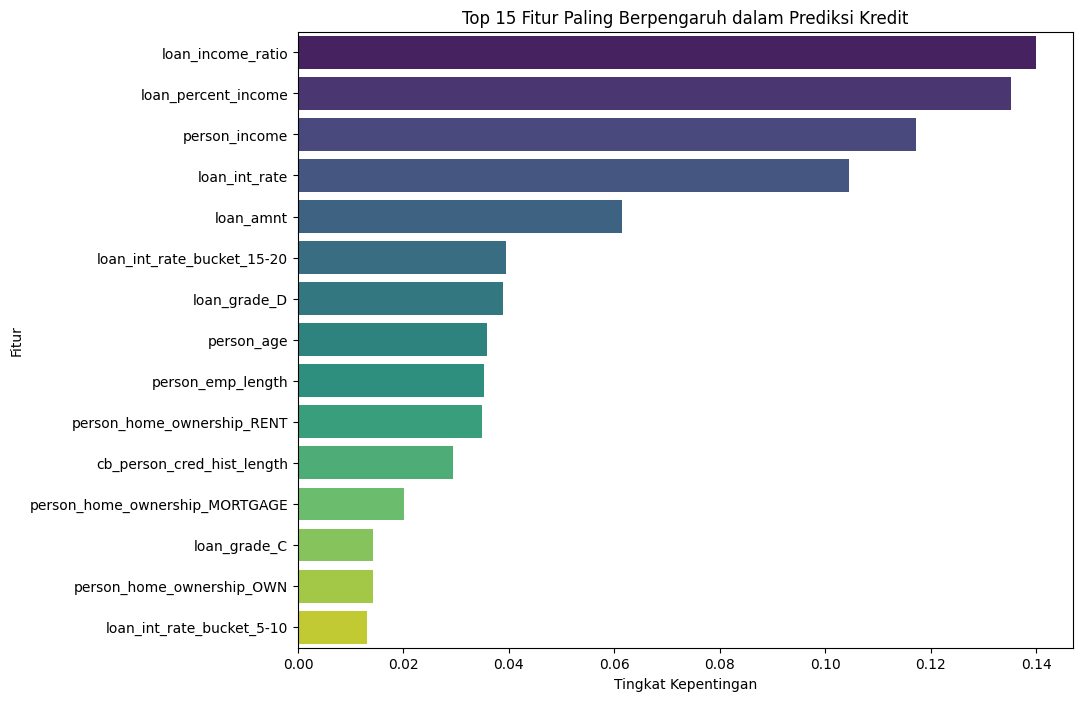

In [14]:
# === Feature importance ===
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mendapatkan fitur dan nilai pentingnya
feature_names = (
    list(numeric_features) + 
    list(grid_search.best_estimator_.named_steps['preprocessor'].transformers_[1][1]['onehot'].get_feature_names_out(categorical_features))
)
importances = grid_search.best_estimator_.named_steps['classifier'].feature_importances_

# 2. Membuat DataFrame agar mudah di-plot
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Visualisasi dengan Bar Chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Fitur Paling Berpengaruh dalam Prediksi Kredit')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.show()

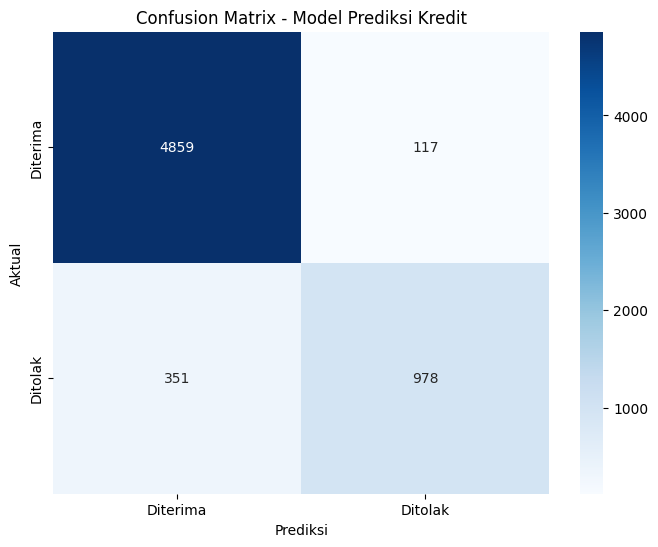


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      4976
           1       0.89      0.74      0.81      1329

    accuracy                           0.93      6305
   macro avg       0.91      0.86      0.88      6305
weighted avg       0.92      0.93      0.92      6305



In [15]:
# === Model evaluation ===
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Mendapatkan prediksi dari model terbaik
y_pred = grid_search.best_estimator_.predict(X_test)

# 2. Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualisasi Confusion Matrix dengan Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Diterima', 'Ditolak'], 
            yticklabels=['Diterima', 'Ditolak'])
plt.title('Confusion Matrix - Model Prediksi Kredit')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# 4. Menampilkan laporan klasifikasi yang lebih detail
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [16]:
# Simpan model terbaik ke folder models/
joblib.dump(grid_search.best_estimator_, '../models/credit_risk_model.pkl')
print("Model berhasil disimpan!")

Model berhasil disimpan!
